# **Heart Attack Risk Classification**

## **Problem Statement**
The goal of this project is to develop a **classification model** that can predict the likelihood of a **heart attack** based on various **patient health indicators**. The dataset contains information on patients' demographic details, medical history, and diagnostic measures. The primary objective is to accurately classify patients into two categories: those with a higher likelihood of experiencing a heart attack (**target = 1**) and those with a lower likelihood (**target = 0**).

**Import libraries**

In [1]:
import pandas as pd
import numpy as np


**Load data**

In [2]:
data = pd.read_csv('heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## **Understanding Variables**
**Age** – Age of the patient in years.

**Sex** – Gender of the patient (M = Male, F = Female).

**ChestPainType** – Type of chest pain experienced by the patient.

**RestingBP** – Blood pressure level when the patient is at rest.

**Cholesterol** – Cholesterol level in the patient’s blood.

**FastingBS** – Whether fasting blood sugar is high (1 = Yes, 0 = No).

**RestingECG** – Result of the resting electrocardiogram test.

**MaxHR** – Maximum heart rate achieved during exercise.

**ExerciseAngina** – Whether chest pain occurs during exercise (Y = Yes, N = No).

**Oldpeak** – ST depression value measured during exercise (heart stress indicator).

**ST_Slope** – Slope pattern of the ST segment during peak exercise.

**HeartDisease** – Whether the patient has heart disease (1 = Yes, 0 = No).

**Basic Checks**

In [3]:
data.shape

(918, 12)

In [4]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [8]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [10]:
cat_cols = data.select_dtypes(include=['object'])
cat_cols

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [11]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
# check for unique values
for x in cat_cols:
  print(x,'--->',data[x].unique())

Sex ---> ['M' 'F']
ChestPainType ---> ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ---> ['Normal' 'ST' 'LVH']
ExerciseAngina ---> ['N' 'Y']
ST_Slope ---> ['Up' 'Flat' 'Down']


In [13]:
# check for value counts
for x in cat_cols:
  print(data[x].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


**Data Cleaning**

**Check for missing values**

In [14]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


**Check for duplicates**

In [15]:
data.duplicated().sum()

np.int64(0)

**Exploratory data analysis**

**Univariate**

1. TA (Typical Angina) – Chest pain caused by reduced blood flow to the heart, usually triggered by physical activity or stress.

2. ATA (Atypical Angina) – Chest discomfort related to the heart but not showing all the typical angina symptoms.

3. NAP (Non-Anginal Pain) – Chest pain not related to heart problems (may be due to muscle, gas, or other causes).

4. ASY (Asymptomatic) – No chest pain symptoms even though a heart problem may still be present.

In [39]:
# finding corr
num_cols.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [41]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Handle Outliers**

In [44]:
df = ['RestingBP','Cholesterol','MaxHR','Oldpeak']
for x in df:
  print(x,'-->',data[x].skew())
  print()

RestingBP --> 0.1798393100516288

Cholesterol --> -0.6100864307268192

MaxHR --> -0.14435941846180994

Oldpeak --> 1.0228720218107528



**Cholesterol**

In [45]:
# IQR method : Cholesterol distribution is skewed
Q1 = data.loc[:,'Cholesterol'].quantile(0.25)
Q3 = data.loc[:,'Cholesterol'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [46]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'Cholesterol']>upper_limit)|(data.loc[:,'Cholesterol']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1
536,62,M,NAP,133,0,1,ST,119,Y,1.2,Flat,1
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
667,65,F,NAP,140,417,1,LVH,157,N,0.8,Up,0


In [47]:
# %
len(data[(data.loc[:,'Cholesterol']>upper_limit)|(data.loc[:,'Cholesterol']<lower_limit)])/len(data)*100

19.934640522875817

Since % of outliers is more than 5% will leave them as it is.

**Oldpeak**

In [48]:
Q1 = data.loc[:,'Oldpeak'].quantile(0.25)
Q3 = data.loc[:,'Oldpeak'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [49]:
data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
68,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1
166,50,M,ASY,140,231,0,ST,140,Y,5.0,Flat,1
324,46,M,ASY,100,0,1,ST,133,N,-2.6,Flat,1
500,65,M,ASY,136,248,0,Normal,140,Y,4.0,Down,1
521,61,M,ASY,120,282,0,ST,135,Y,4.0,Down,1
537,74,M,ASY,150,258,1,ST,130,Y,4.0,Down,1
559,64,M,ASY,134,273,0,Normal,102,Y,4.0,Down,1
624,63,F,ASY,150,407,0,LVH,154,N,4.0,Flat,1
702,59,M,TA,178,270,0,LVH,145,N,4.2,Down,0
732,56,F,ASY,200,288,1,LVH,133,Y,4.0,Down,1


In [50]:
len(data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

1.7429193899782136

In [51]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'Oldpeak']>upper_limit)|
 (data.loc[:,'Oldpeak']<lower_limit),'Oldpeak']=data.loc[:,'Oldpeak'].median()

In [52]:
len(data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

0.0

**RestingBP**

In [53]:
mean_val = data.loc[:,'RestingBP'].mean()
std_val = data.loc[:,'RestingBP'].std()
upper_limit = mean_val + 3*std_val
lower_limit = mean_val - 3* std_val

In [54]:
data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1
365,64,F,ASY,200,0,0,Normal,140,Y,1.0,Flat,1
399,61,M,NAP,200,0,1,ST,70,N,0.0,Flat,1
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1
592,61,M,ASY,190,287,1,LVH,150,Y,2.0,Down,1
732,56,F,ASY,200,288,1,LVH,133,Y,0.6,Down,1
759,54,M,ATA,192,283,0,LVH,195,N,0.0,Up,1


In [55]:
len(data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)])/len(data)*100

0.8714596949891068

In [56]:
data.loc[(data.loc[:,'RestingBP']>upper_limit)|
 (data.loc[:,'RestingBP']<lower_limit),'RestingBP']=data.loc[:,'RestingBP'].mean()

/tmp/ipykernel_3883/734573612.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.39651416122004' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'RestingBP']>upper_limit)|


**MaxHR**

In [57]:
mean_val = data.loc[:,'MaxHR'].mean()
std_val = data.loc[:,'MaxHR'].std()
upper_limit = mean_val + 3*std_val
lower_limit = mean_val - 3* std_val

In [58]:
data[(data.loc[:,'MaxHR']>upper_limit)|(data.loc[:,'MaxHR']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
390,51,M,ASY,140.0,0,0,Normal,60,N,0.0,Flat,1


In [59]:
data.loc[(data.loc[:,'MaxHR']>upper_limit)|
 (data.loc[:,'MaxHR']<lower_limit),'MaxHR']=data.loc[:,'MaxHR'].mean()

/tmp/ipykernel_3883/3454964119.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.80936819172112' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'MaxHR']>upper_limit)|


# Encoding

In [60]:
# Sex	, ExerciseAngina	,ST_Slope,RestingECG,ChestPainType

In [61]:
# ExerciseAngina
from sklearn.preprocessing import LabelEncoder
scaler = LabelEncoder()
data.loc[:,'Exercise_Angina']=scaler.fit_transform(data.loc[:,'ExerciseAngina'])

In [62]:
# Sex
data = pd.get_dummies(data,columns=['Sex'],dtype='int')

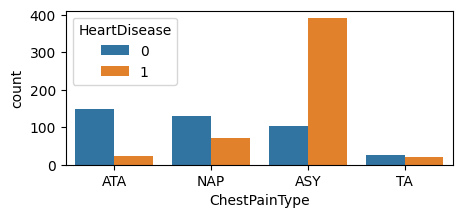

In [63]:
# ChestPainType
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType',hue='HeartDisease')
plt.show()

In [64]:
# use map
data.loc[:,'Chest_PainType']=data.loc[:,'ChestPainType'].map({'ASY':3,'NAP':2,'ATA':1,'TA':0})

**RestingECG**

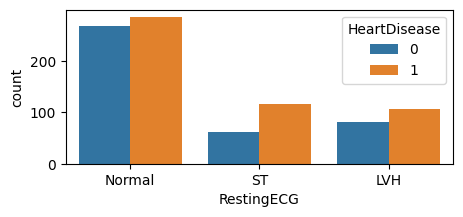

In [65]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='RestingECG',hue='HeartDisease')
plt.show()

In [66]:
data.loc[:,'Resting_ECG']= data.loc[:,'RestingECG'].map({'Normal':0,'LVH':1,'ST':2})

**ST_Slope**

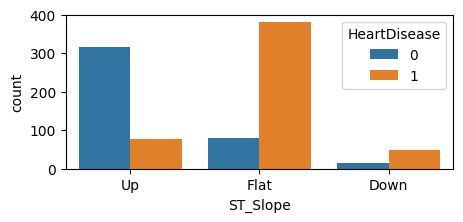

In [67]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='ST_Slope',hue='HeartDisease')
plt.show()

In [68]:
data.loc[:,'st_Slope']= data.loc[:,'ST_Slope'].map({'Down':0,'Up':1,'Flat':2})

In [69]:
data.drop(columns=['ChestPainType','ExerciseAngina','ST_Slope','RestingECG'],inplace=True)

# scaling

In [70]:
# standard scaler
#Age	RestingBP	Cholesterol MaxHR
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Age']]=scaler.fit_transform(data[['Age']])
data[['RestingBP']]=scaler.fit_transform(data[['RestingBP']])
data[['Cholesterol']]=scaler.fit_transform(data[['Cholesterol']])
data[['MaxHR']]=scaler.fit_transform(data[['MaxHR']])


In [71]:
data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Exercise_Angina,Sex_F,Sex_M,Chest_PainType,Resting_ECG,st_Slope
0,-1.433140,0.464762,0.825070,0,1.386546,0.0,0,0,0,1,1,0,1
1,-0.478484,1.634819,-0.171961,0,0.754627,1.0,1,0,1,0,2,0,2
2,-1.751359,-0.120267,0.770188,0,-1.536076,0.0,0,0,0,1,1,2,1
3,-0.584556,0.347756,0.139040,0,-1.141127,1.5,1,1,1,0,3,0,2
4,0.051881,1.049790,-0.034755,0,-0.588199,0.0,0,0,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.290324,0.596393,0,-0.193250,1.2,1,0,0,1,0,0,2
914,1.536902,0.698773,-0.053049,1,0.162204,3.4,1,0,0,1,3,0,2
915,0.370100,-0.120267,-0.620168,0,-0.864663,1.2,1,1,0,1,3,0,2
916,0.370100,-0.120267,0.340275,0,1.465535,0.0,1,0,1,0,1,1,2


# feature Engineering

In [72]:
# nothing to drop

# Split data for x and y

In [73]:
x=data.drop(columns=['HeartDisease'])
y= data.loc[:,'HeartDisease']

# Split data for training and testing

In [74]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

 Balancing data


In [76]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)
# Balancing should be done only on training data

# Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [78]:
model.coef_

array([[ 0.19300853, -0.01713876, -0.39860544,  1.21061805, -0.22771811,
         0.65962684,  1.33696383,  0.13287351,  1.15544218,  0.65290092,
        -0.04631213,  1.16264215]])

In [79]:
model.intercept_

array([-5.24464928])

In [80]:
model.predict_proba(x_test)

array([[0.96996136, 0.03003864],
       [0.82968463, 0.17031537],
       [0.04029862, 0.95970138],
       [0.0449222 , 0.9550778 ],
       [0.94338348, 0.05661652],
       [0.20028773, 0.79971227],
       [0.31213682, 0.68786318],
       [0.79039852, 0.20960148],
       [0.50135092, 0.49864908],
       [0.2216181 , 0.7783819 ],
       [0.66786742, 0.33213258],
       [0.75040466, 0.24959534],
       [0.38644261, 0.61355739],
       [0.89918979, 0.10081021],
       [0.13655631, 0.86344369],
       [0.19431383, 0.80568617],
       [0.93619541, 0.06380459],
       [0.50759969, 0.49240031],
       [0.35394369, 0.64605631],
       [0.84783241, 0.15216759],
       [0.67156042, 0.32843958],
       [0.26950046, 0.73049954],
       [0.92170865, 0.07829135],
       [0.26052043, 0.73947957],
       [0.39871964, 0.60128036],
       [0.13336525, 0.86663475],
       [0.9405145 , 0.0594855 ],
       [0.23369657, 0.76630343],
       [0.95460624, 0.04539376],
       [0.96125121, 0.03874879],
       [0.

# **Evaluate the model**

In [81]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [82]:
confusion_matrix(y_test,y_pred)

array([[70,  7],
       [22, 85]])

In [83]:
accuracy_score(y_test,y_pred)

0.842391304347826

In [84]:
recall_score(y_test,y_pred)

0.794392523364486

In [85]:
precision_score(y_test,y_pred)

0.9239130434782609

In [86]:
f1_score(y_test,y_pred)

0.8542713567839196

# KNN Classifier

In [87]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

model = KNeighborsClassifier(n_neighbors=7)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


In [89]:
confusion_matrix(y_test, y_pred)


array([[68,  9],
       [19, 88]])

In [90]:
accuracy_score(y_test, y_pred)


0.8478260869565217

In [91]:
precision_score(y_test, y_pred)


0.9072164948453608

In [92]:
recall_score(y_test, y_pred)

0.822429906542056

In [93]:
f1_score(y_test, y_pred)

0.8627450980392157

how to find K

In [94]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [95]:
r2 = r2_score(y_test, y_pred)
r2

0.37468139337298223

In [96]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mape

np.float64(inf)

In [97]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.15217391304347827

In [98]:
mse = mean_squared_error(y_test, y_pred)
mse

0.15217391304347827

In [99]:
rmse = np.sqrt(mse)
rmse

np.float64(0.39009474880274697)

In [100]:
error = []
for k in range(2, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_sampled, y_sampled)
    y_pred = model.predict(x_test)

    error.append(np.mean(y_pred != y_test))

print(error)

[np.float64(0.2391304347826087), np.float64(0.15760869565217392), np.float64(0.20108695652173914), np.float64(0.14673913043478262), np.float64(0.1793478260869565), np.float64(0.15760869565217392), np.float64(0.1793478260869565), np.float64(0.15760869565217392), np.float64(0.17391304347826086)]


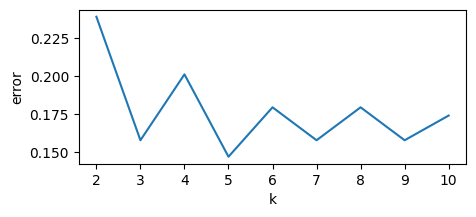

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,2))
plt.plot(range(2,11), error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

decision trre classifier


In [102]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_sampled, y_sampled)

DecisionTreeClassifier()

In [103]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[72  5]
 [27 80]]
0.8260869565217391
0.9411764705882353
0.7476635514018691
0.8333333333333334


In [104]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',max_depth=50,max_features='sqrt',splitter='best', min_samples_leaf=6, min_samples_split=5)
model.fit(x_sampled, y_sampled)

DecisionTreeClassifier(max_depth=50, max_features='sqrt', min_samples_leaf=6,
                       min_samples_split=5)

In [105]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[72  5]
 [27 80]]
0.8260869565217391
0.9411764705882353
0.7476635514018691
0.8333333333333334


Random forest Classifier


In [106]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [107]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[67 10]
 [12 95]]
0.8804347826086957
0.9047619047619048
0.8878504672897196
0.8962264150943396


In [108]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=50,max_depth=10,criterion='gini',max_features='sqrt',min_samples_split=5,min_samples_leaf=6,bootstrap=True)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [109]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[66 11]
 [ 9 98]]
0.8913043478260869
0.8990825688073395
0.9158878504672897
0.9074074074074074




Gradient Boosting classifier

In [110]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=50,max_depth=10,max_features='sqrt',learning_rate=0.01,min_samples_split=5,min_samples_leaf=6)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [111]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

[[65 12]
 [10 97]]
0.8804347826086957
0.8899082568807339
0.9065420560747663
0.8981481481481481


In [ ]:
import joblib
model = joblib.load("model_gb.pkl")